# ДЗ №3. Задача регресси на kaggle

Вам предлагается разработать алгоритмы машинного обучения, которые позволяют установить связь между химическим составом, различными свойствами сверхпроводниками и их критической температурой.

In [227]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Датасет с признаками:

In [228]:
train = pd.read_csv('train.csv')
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [229]:
missing_counts_1 = train.isna().sum()
print(missing_counts_1[missing_counts_1 > 0])

Series([], dtype: int64)


Датасет с формулами:

In [230]:
formula_train = pd.read_csv('formula_train.csv')
formula_train.head()

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [231]:
missing_counts_2 = formula_train.isna().sum()
print(missing_counts_2[missing_counts_2 > 0])

Series([], dtype: int64)


In [232]:
# Объединяем данные
formula_train = formula_train.drop(columns=['critical_temp'])
train_full = pd.concat([train, formula_train], axis=1)
train_full.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,material
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.2La1.8Cu1O4
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.1La1.9Ag0.1Cu0.9O4
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.1La1.9Cu1O4
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.15La1.85Cu1O4
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.3La1.7Cu1O4


In [233]:
train_full.drop(columns=['material'], inplace=True)

### Информация о целевой переменной

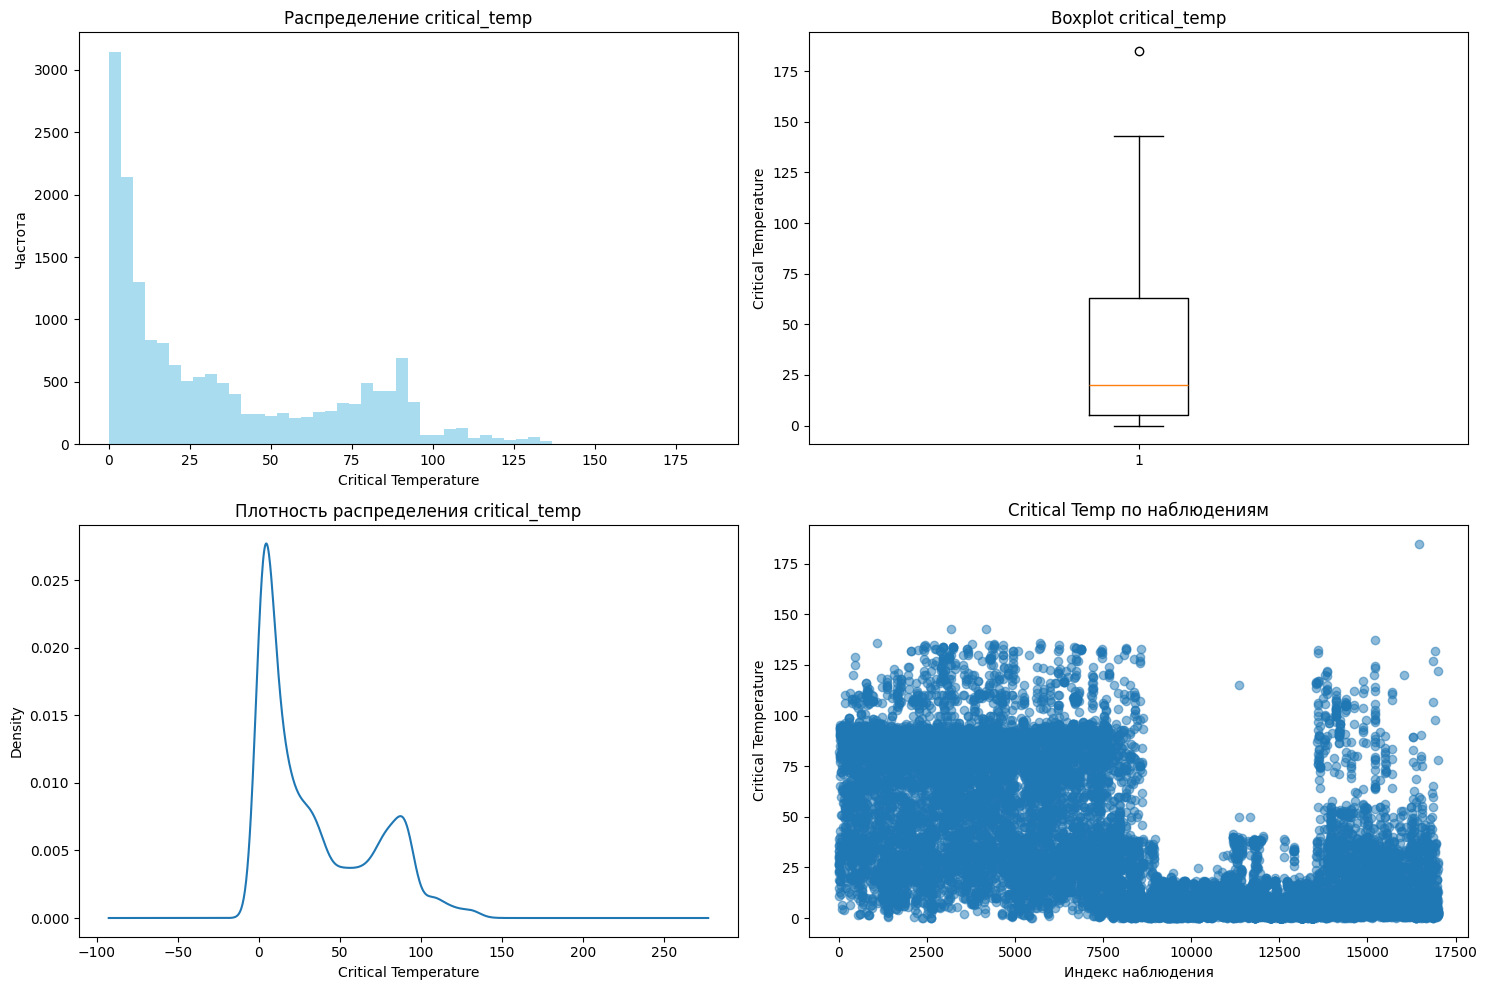

count    17010.000000
mean        34.502993
std         34.334793
min          0.000210
25%          5.330000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64


In [234]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# гистограмма
axes[0,0].hist(train['critical_temp'], bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('Распределение critical_temp')
axes[0,0].set_xlabel('Critical Temperature')
axes[0,0].set_ylabel('Частота')

# boxplot
axes[0,1].boxplot(train['critical_temp'])
axes[0,1].set_title('Boxplot critical_temp')
axes[0,1].set_ylabel('Critical Temperature')

# плотность распределения
train['critical_temp'].plot.kde(ax=axes[1,0])
axes[1,0].set_title('Плотность распределения critical_temp')
axes[1,0].set_xlabel('Critical Temperature')

# точечный график (по индексу)
axes[1,1].scatter(range(len(train)), train['critical_temp'], alpha=0.5)
axes[1,1].set_title('Critical Temp по наблюдениям')
axes[1,1].set_xlabel('Индекс наблюдения')
axes[1,1].set_ylabel('Critical Temperature')

plt.tight_layout()
plt.show()

# базовая статистика
print(train['critical_temp'].describe())

In [235]:
# Рассмотрим выброс
outliers = train[train['critical_temp'] > 175]
print(outliers[['critical_temp']])

       critical_temp
16461          185.0


In [236]:
train_full = train_full.drop(train_full.index[16460])

In [237]:
corr = train.corr().abs()
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            high_corr_pairs.append((col1, col2, corr.iloc[i, j]))
for col1, col2, value in high_corr_pairs:
    print(f"{col1} — {col2}: {value:.4f}")

number_of_elements — entropy_fie: 0.9729
number_of_elements — entropy_atomic_radius: 0.9719
number_of_elements — entropy_Valence: 0.9676
wtd_mean_atomic_mass — wtd_gmean_atomic_mass: 0.9650
entropy_atomic_mass — entropy_fie: 0.9650
entropy_atomic_mass — entropy_atomic_radius: 0.9727
entropy_atomic_mass — entropy_Valence: 0.9636
wtd_entropy_atomic_mass — wtd_entropy_atomic_radius: 0.9621
range_atomic_mass — std_atomic_mass: 0.9612
mean_fie — gmean_fie: 0.9694
wtd_mean_fie — wtd_gmean_fie: 0.9923
entropy_fie — entropy_atomic_radius: 0.9977
entropy_fie — entropy_Valence: 0.9927
range_fie — std_fie: 0.9816
wtd_mean_atomic_radius — wtd_gmean_atomic_radius: 0.9801
entropy_atomic_radius — entropy_Valence: 0.9895
wtd_entropy_atomic_radius — wtd_entropy_Valence: 0.9517
range_atomic_radius — std_atomic_radius: 0.9675
range_atomic_radius — wtd_std_atomic_radius: 0.9579
gmean_Density — wtd_gmean_Density: 0.9515
range_Density — std_Density: 0.9602
range_ElectronAffinity — std_ElectronAffinity: 0.97

In [238]:
train.iloc[16461, :]

number_of_elements         2.000000
mean_atomic_mass          16.536470
wtd_mean_atomic_mass      11.360293
gmean_atomic_mass          5.685033
wtd_gmean_atomic_mass      3.193745
                            ...    
range_Valence              5.000000
wtd_range_Valence          1.333333
std_Valence                2.500000
wtd_std_Valence            2.357023
critical_temp            185.000000
Name: 16461, Length: 82, dtype: float64

In [239]:
formula_train.iloc[16461, :]

H            2.0
He             0
Li           0.0
Be           0.0
B            0.0
            ... 
Bi           0.0
Po             0
At             0
Rn             0
material    H2S1
Name: 16461, Length: 87, dtype: object

### Обучение модели

$y = w_{0} + W*X$

$y = w_{0} + w_{1}*x_{1} + w_{2}*x_{2} + ... + w_{167}*x_{167}$

$W = [w_{1},w_{2},...,w_{167}]$

$X = [x_{1},x_{2},...,x_{167}]$

Задача линейной регрессии сводится к рассчёту коэффициентов (весов $w_{i}$) при признаках $x_{i}$.

In [240]:
# Выделим из набора данных вектор признаков и вектор ответов
X = train_full.drop(columns=['critical_temp'])
y = train_full['critical_temp']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (17009, 167)
Target shape: (17009,)


In [241]:
from sklearn.model_selection import train_test_split

X_train, X_test_e, y_train, y_test_e = train_test_split(X, y, test_size=0.2, random_state=15)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Train dataset size: {X_test_e.shape}, {y_test_e.shape}')

Train dataset size: (13607, 167), (13607,)
Train dataset size: (3402, 167), (3402,)


In [242]:
from sklearn.preprocessing import StandardScaler

In [243]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [244]:
# для решения используем алгоритм линейной регрессии
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [245]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [246]:
print('Веса (w1, ... ,w167): ', model.coef_)
print('w0: ', model.intercept_)

Веса (w1, ... ,w167):  [ 1.48042059e+00  2.71100915e+01 -4.09266719e+01 -1.32765141e+01
  2.48176118e+01 -7.45395704e+00 -3.98280584e-01  1.17140217e+01
  2.80401651e+00 -1.14228096e+01  4.88987197e-01 -1.28948199e+01
  1.51123528e+00  8.94721303e+00  4.64152930e+00 -3.09089621e+00
  1.93165641e+01  1.33493471e+01  3.46941811e+00 -1.05348224e+01
 -2.84294995e+00 -1.36757348e+01  6.27318730e+01  9.46130439e+00
 -6.84802219e+01 -8.22323562e+00  7.76831508e+00  3.75418734e+00
 -2.76890959e+00 -5.66191970e+00 -2.55395400e+00 -1.49380345e+01
  1.39271225e+01  1.32467835e+00  9.78459517e-01 -3.02532257e+00
 -2.51182097e-02 -4.34151952e+00 -1.44852401e+00  6.29301735e+00
 -1.95557000e+00 -1.30586265e+00  1.09461734e+01  3.70497733e+00
 -1.33616057e+01  2.83682955e+00 -5.40548868e+00 -2.04866316e+01
 -1.95380590e+00  2.63015185e+01 -1.03192367e+01  1.54639973e+01
 -2.72771517e+01 -9.89687343e+00  1.85639761e+01 -7.61630597e+00
  8.65038423e+00 -3.16205374e+00  6.95123416e+00 -8.25411644e+00
  

In [247]:
X_test_e = scaler.fit_transform(X_test_e)

In [248]:
y_pred_test = model.predict(X_test_e)
print(y_test_e)
print(y_pred_test)

4647     95.00
13732     6.10
14811    17.10
16465     4.50
13465     9.42
         ...  
7019     29.00
193      88.60
15275    18.00
2308     35.10
11216     6.80
Name: critical_temp, Length: 3402, dtype: float64
[72.25671755 11.86271297 20.08307184 ...  9.36113931 57.44907631
 -2.50590943]


In [249]:
print('MAE:', mean_absolute_error(y_test_e, y_pred_test))
print('MSE:', mean_squared_error(y_test_e, y_pred_test))
print('R2 score:', r2_score(y_test_e, y_pred_test))

MAE: 12.310533512493953
MSE: 265.2202291815269
R2 score: 0.7702349968083021


### Проверим на тестовых данных

In [250]:
test = pd.read_csv('test.csv')
formula_test = pd.read_csv("formula_test.csv")

In [251]:
missing1 = test.isna().sum()
missing2 = formula_test.isna().sum()
print(missing1[missing1>0])
print(missing2[missing2>0])

Series([], dtype: int64)
Series([], dtype: int64)


In [252]:
test_full = pd.concat([test, formula_test], axis=1)
test_full.drop(columns=['material'], inplace=True)

In [253]:
X_test = test_full
X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

In [254]:
submit_index = range(len(X_test_scaled))
submission = pd.DataFrame({
    "index": submit_index,
    "critical_temp": y_pred
})
submission.to_csv("submission.csv", index=False)